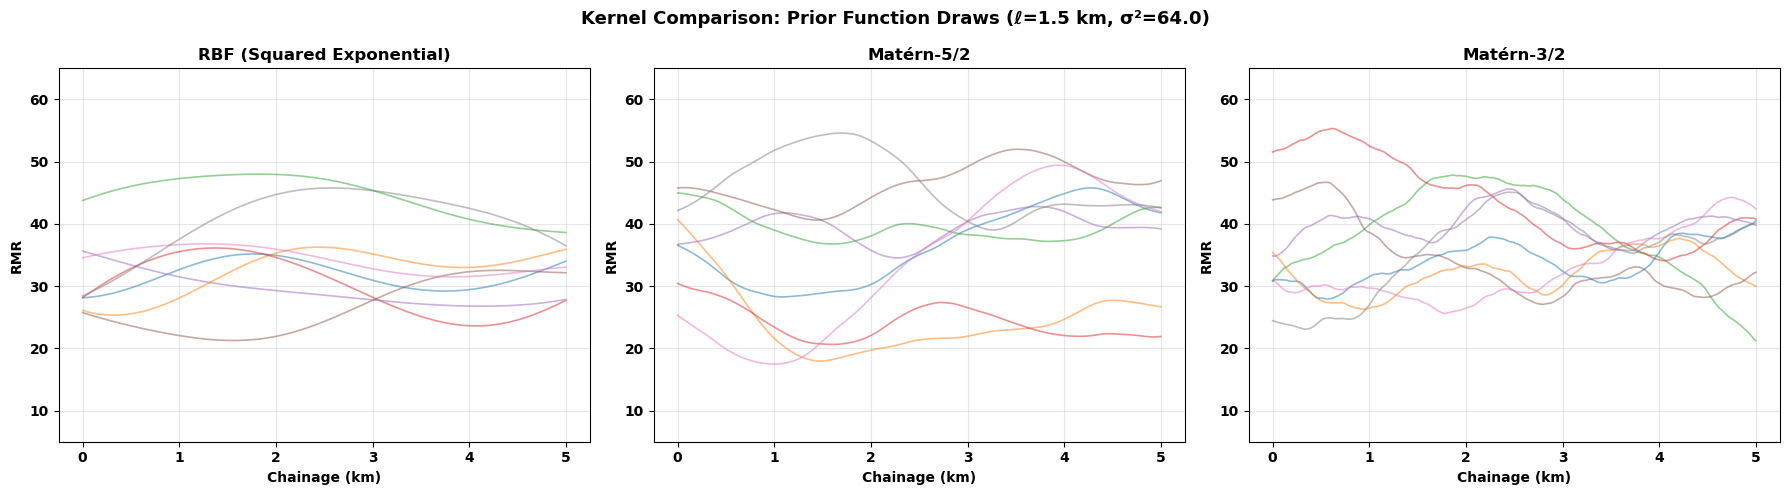

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

np.random.seed(42)

# kernel is the prior
# choosing kernel is as imp as choosing the prior distro
# know what kernel believs about the data

# to make more robust do the at least 2d code

def rbf_kernel(x1, x2, sigma_sq, ell):
    """Squared Exponential / RBF / Exponentiated Quadratic kernel.
    k(r) = σ² exp(-r² / 2ℓ²)
    Produces INFINITELY smooth (C∞) functions.
    """
    r = cdist(x1.reshape(-1,1), x2.reshape(-1,1), metric='euclidean')
    dist_sq = r ** 2
    # sq cuz formula needs squared anyway
    return sigma_sq * np.exp(-dist_sq / (2 * ell**2))


def matern52_kernel(x1, x2, sigma_sq, ell):
    """Matérn-5/2 kernel.
    k(r) = σ² (1 + √5r/ℓ + 5r²/3ℓ²) exp(-√5r/ℓ)
    Produces TWICE-differentiable (C²) functions.
    More realistic for physical processes — allows small-scale roughness.
    """
    dist = cdist(x1.reshape(-1,1), x2.reshape(-1,1), metric='euclidean')
    r = dist / ell
    sqrt5_r = np.sqrt(5) * r
    return sigma_sq * (1 + sqrt5_r + 5 * r**2 / 3) * np.exp(-sqrt5_r)


def matern32_kernel(x1, x2, sigma_sq, ell):
    """Matérn-3/2 kernel.
    k(r) = σ² (1 + √3r/ℓ) exp(-√3r/ℓ)
    Produces ONCE-differentiable (C¹) functions (breaks when 2nd derivative).
    Even rougher than Matérn-5/2. Good for very noisy spatial fields.
    """
    dist = cdist(x1.reshape(-1,1), x2.reshape(-1,1), metric='euclidean')
    r = dist / ell
    sqrt3_r = np.sqrt(3) * r
    return sigma_sq * (1 + sqrt3_r) * np.exp(-sqrt3_r)


# diff once doesnt mean like a linear fxn, its diff infinitely cuz d(0) is also 0
# what it means is undefined like the |x| fxn at x=0, no defined tangent line (slope)

# drawing prior from each kernel
# fxn draw without observed

x = np.linspace(0, 5, 200)
sigma_sq = 64.0
ell = 1.5

kernels = {
    'RBF (Squared Exponential)': rbf_kernel,
    'Matérn-5/2': matern52_kernel,
    'Matérn-3/2': matern32_kernel,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, kernel_fn) in zip(axes, kernels.items()):
    K = kernel_fn(x, x, sigma_sq, ell) + 1e-6 * np.eye(len(x))
    samples = np.random.multivariate_normal(np.full(len(x), 35.0), K, size=8)

    for s in samples:
        ax.plot(x, s, alpha=0.5, linewidth=1.2)

    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Chainage (km)')
    ax.set_ylabel('RMR')
    ax.set_ylim(5, 65)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Kernel Comparison: Prior Function Draws (ℓ={ell} km, σ²={sigma_sq})',
             fontsize=13)
plt.tight_layout()
plt.show()

#RBF: Functions are VERY smooth — almost sinusoidal. Unrealistically smooth
#for geological data. RMR doesn't vary this smoothly in real rock.
#Matérn-5/2: Functions are smooth but have small-scale irregularities.
#THIS is the default for geotechnical/spatial data.")
#Matérn-3/2: Functions are rough — jagged, with sharp changes.
#Use this if you expect abrupt geological transitions (fault zones).

#WHY MATÉRN-5/2 IS DEFAULT:
#It is twice differentiable (C²) — smooth enough for interpolation
#But NOT infinitely smooth like RBF — allows realistic roughness
#R&W Section 4.2.1: 'the Matérn class should be the default for most applications'
#PyMC's pm.gp.cov.Matern52 implements this directly


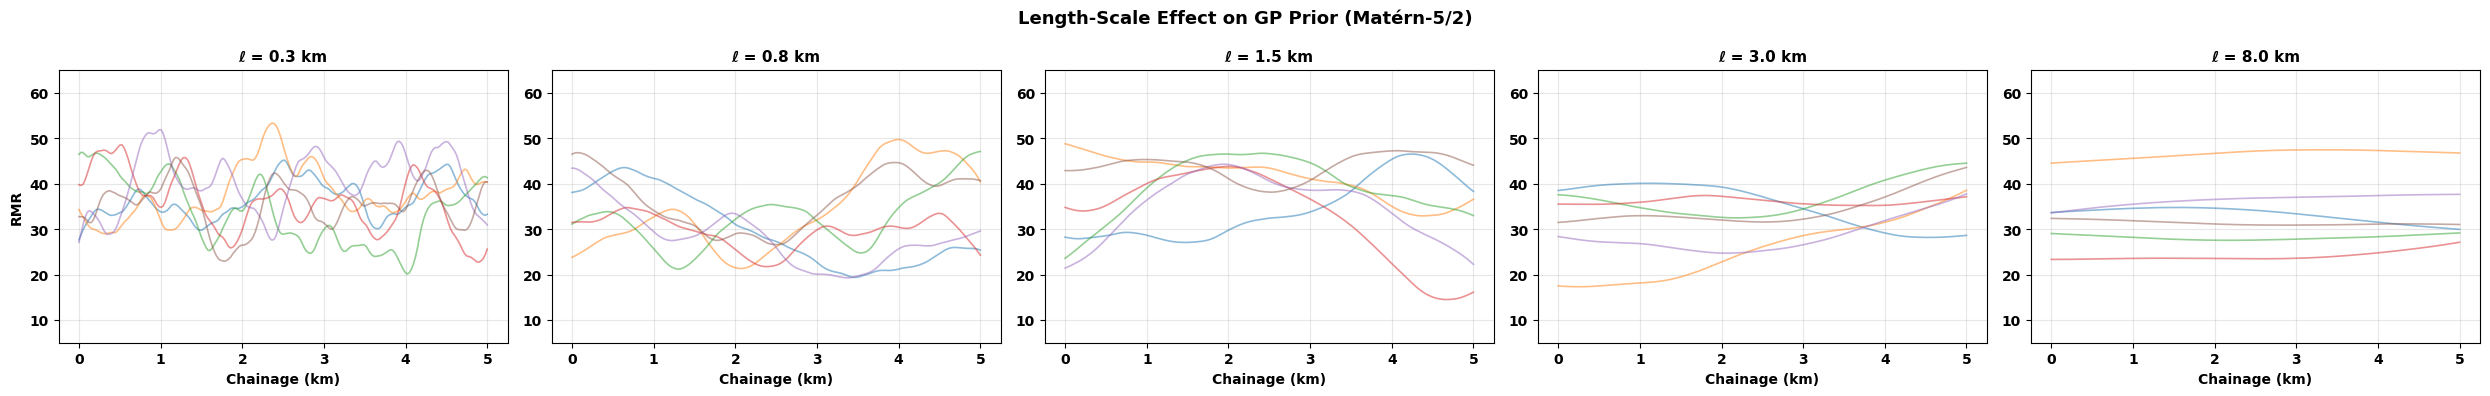

In [5]:
#length_scale: most op hyperparameter

# Short ℓ = each borehole is an island (wiggly functions)
# Long ℓ = boreholes inform each other over large distances (smooth functions)
# compare that with partial pool

length_scales = [0.3, 0.8, 1.5, 3.0, 8.0]
x = np.linspace(0, 5, 200)
sigma_sq = 64.0

fig, axes = plt.subplots(1, 5, figsize=(25, 4))
for ax, ell in zip(axes, length_scales):
    K = matern52_kernel(x, x, sigma_sq, ell) + 1e-6 * np.eye(len(x))
    samples = np.random.multivariate_normal(np.full(len(x), 35.0), K, size=6)

    for s in samples:
        ax.plot(x, s, alpha=0.5, linewidth=1.2)

    ax.set_title(f'ℓ = {ell} km', fontsize=11, fontweight='bold')
    ax.set_xlabel('Chainage (km)')
    if ell == length_scales[0]:
        ax.set_ylabel('RMR')
    ax.set_ylim(5, 65)
    ax.grid(True, alpha=0.3)

plt.suptitle('Length-Scale Effect on GP Prior (Matérn-5/2)', fontsize=13)
plt.tight_layout()
plt.show()

#ℓ = 0.3 km: Chaotic. Every point is nearly independent.
#→ Highly faulted, heterogeneous rock mass
# ℓ = 0.8 km: Wiggly but structured. Short-range correlation.
#→ Mixed rock with frequent lithological changes
#ℓ = 1.5 km: Moderate smoothness. The 'safe default' for most tunnels.
# → Typical Himalayan metamorphic rock
# ℓ = 3.0 km: Very smooth. Long-range geological consistency.
# → Massive granite or thick sedimentary sequence
# ℓ = 8.0 km: Almost constant. The GP thinks the whole tunnel is one rock.
# → Unrealistic for most real geological settings
# IN PYMC: we don't fix ℓ. we put a PRIOR on it (e.g., InverseGamma)
# and let NUTS estimate the posterior of ℓ from the data.
# "The data TELLS us the actual spatial correlation range.